# ASR Analysis: Score vs Number of Samples (Direct Request Only)

This notebook analyzes the relationship between attack success rate scores and the number of samples used, focusing on direct_request data from batch_1 with 3 samples per combination.

We use the theoretical formula for expected maximum of s samples from n=3 observations:

$$\operatorname{E}[M] = \frac{1}{\binom{n}{s}} \sum_{k=s}^{n} x_{(k)} \binom{k-1}{s-1}$$

where $x_{(1)} \le x_{(2)} \le x_{(3)}$ are the ordered scores.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb
from scipy.optimize import curve_fit
import ast
from typing import Dict, List

# Set style to match reference notebook
plt.style.use('default')

In [2]:
# Helper function to safely parse scores
def parse_scores(score_str):
    """Parse score string to list of floats"""
    try:
        if pd.isna(score_str) or score_str == '[]':
            return []
        # Handle string representation of list
        if isinstance(score_str, str):
            return ast.literal_eval(score_str)
        return score_str
    except:
        return []

# Function to calculate expected maximum for s samples from n=3 observations
def expected_max_formula(scores, s, n=3):
    """Calculate expected maximum using the theoretical formula"""
    if len(scores) != n:
        return np.nan
    
    # Sort scores to get order statistics
    x_ordered = sorted(scores)
    
    # Calculate expected maximum
    expected_val = 0.0
    for k in range(s, n + 1):
        # x_(k) is the k-th order statistic (1-indexed)
        x_k = x_ordered[k - 1]  # Convert to 0-indexed
        
        # Binomial coefficient C(k-1, s-1)
        binom_coeff = comb(k - 1, s - 1, exact=True)
        
        expected_val += x_k * binom_coeff
    
    # Normalize by C(n, s)
    expected_val /= comb(n, s, exact=True)
    
    return expected_val

In [3]:
# Load and filter data to direct_request from batch_1
df = pd.read_csv('/home/dcruz/multi_turn_jailbreaks/csv_results/master_results.csv')
print(f"Total rows in dataset: {len(df)}")

# Filter to batch_1 and direct_request only (this mirrors the reference notebook's focus)
batch1_direct = df[(df['batch'] == 'batch_1') & (df['jailbreak_tactic'] == 'direct_request')].copy()
print(f"Rows in batch_1 direct_request: {len(batch1_direct)}")

# Parse scores and get max score for each row
batch1_direct['parsed_scores'] = batch1_direct['scores'].apply(parse_scores)
batch1_direct['max_score'] = batch1_direct['parsed_scores'].apply(lambda x: max(x) if x else 0.0)

print(f"Turn type distribution:")
print(batch1_direct['turn_type'].value_counts())

Total rows in dataset: 14173
Rows in batch_1 direct_request: 1260
Turn type distribution:
turn_type
single    630
multi     630
Name: count, dtype: int64


In [4]:
# Create combination identifier (test_case + model + turn_type + temp)
batch1_direct['combination'] = (batch1_direct['test_case'] + '_' + 
                               batch1_direct['target_model'] + '_' + 
                               batch1_direct['turn_type'] + '_' + 
                               batch1_direct['target_temp'].astype(str))

# Count samples per combination
combination_counts = batch1_direct['combination'].value_counts()
print("Sample count distribution:")
print(combination_counts.value_counts().sort_index())

# Filter to combinations with exactly 3 samples
combinations_with_3 = combination_counts[combination_counts == 3].index
batch1_3samples = batch1_direct[batch1_direct['combination'].isin(combinations_with_3)].copy()

print(f"\nCombinations with exactly 3 samples: {len(combinations_with_3)}")
print(f"Total rows with 3-sample combinations: {len(batch1_3samples)}")

Sample count distribution:
count
3    420
Name: count, dtype: int64

Combinations with exactly 3 samples: 420
Total rows with 3-sample combinations: 1260


In [5]:
# Calculate expected maximums for s=1,2,3 samples for each combination
# This creates the equivalent of max_score_by_s_sample columns
combination_data = []

for combo in combinations_with_3:
    combo_rows = batch1_3samples[batch1_3samples['combination'] == combo]
    scores = combo_rows['max_score'].tolist()
    
    if len(scores) == 3:
        # Calculate expected maximums for s=1,2,3
        exp_max_1 = expected_max_formula(scores, 1)
        exp_max_2 = expected_max_formula(scores, 2) 
        exp_max_3 = expected_max_formula(scores, 3)
        
        # Extract metadata from combination
        first_row = combo_rows.iloc[0]
        
        combination_data.append({
            'combination': combo,
            'test_case': first_row['test_case'],
            'target_model': first_row['target_model'],
            'turn_type': first_row['turn_type'],
            'target_temp': first_row['target_temp'],
            'scores': scores,
            'max_score_by_1_sample': exp_max_1,
            'max_score_by_2_sample': exp_max_2,
            'max_score_by_3_sample': exp_max_3
        })

metadata = pd.DataFrame(combination_data)
print(f"Successfully processed {len(metadata)} combinations")
print(f"Models: {sorted(metadata['target_model'].unique())}")
print(f"Turn types: {metadata['turn_type'].value_counts()}")

Successfully processed 420 combinations
Models: ['gpt-4o-mini-2024-07-18', 'meta-llama/llama-3.1-405b-instruct', 'meta-llama/llama-3.1-70b-instruct', 'meta-llama/llama-3.1-8b-instruct', 'meta-llama/llama-3.2-1b-instruct', 'meta-llama/llama-3.2-3b-instruct', 'meta-llama/llama-3.3-70b-instruct']
Turn types: turn_type
multi     210
single    210
Name: count, dtype: int64


In [6]:
# Functions to analyze and plot (adapted from reference notebook)
def get_max_score_columns(df: pd.DataFrame) -> tuple:
    """Get the max score columns from the DataFrame."""
    max_score_columns = [col for col in df.columns if col.startswith('max_score_by_') and col.endswith('_sample')]
    
    # Extract s values from column names
    s_values = []
    for col in max_score_columns:
        s = col.replace('max_score_by_', '').replace('_sample', '')
        s_values.append(int(s))
    
    # Sort to ensure proper order
    s_values.sort()
    max_score_columns = [f'max_score_by_{s}_sample' for s in s_values]
    
    return max_score_columns, s_values

def analyze_max_scores_by_model(df: pd.DataFrame) -> Dict:
    """Calculate average maximum scores by sample count for each target model."""
    max_score_columns, s_values = get_max_score_columns(df)
    results = {}
    
    # Group by target_model only (since we're only using direct_request data)
    for model in df['target_model'].unique():
        model_data = df[df['target_model'] == model]
        
        avg_max_scores = []
        for col in max_score_columns:
            avg_score = model_data[col].mean()
            avg_max_scores.append(avg_score)
        
        # Create DataFrame for this model
        model_results = pd.DataFrame({
            's': s_values,  # Using 's' instead of 'k' to represent sample count
            'avg_max_score': avg_max_scores
        })
        
        results[model] = model_results
    
    return results

In [7]:
# Define fitting function (same as reference notebook)
def formula(s, A, B, c):
    return A - B * np.exp(-c * s)

def fit_formula(s_data, y_data):
    """Fit the model to the data using curve fitting."""
    # Initial guess for parameters A, B, c
    initial_guess = [1.0, 0.5, 1.0]
    
    # Fit the model to the data
    params, covariance = curve_fit(formula, s_data, y_data, p0=initial_guess)
    
    return params

In [8]:
def plot_curve_fit(s_data, y_data):
    """Plot the original data and the fitted curve (adapted from reference notebook)."""
    plt.figure(figsize=(10, 6))
    plt.scatter(s_data, y_data, label='Data', color='blue')
    
    # Generate fitted curve
    params = fit_formula(s_data, y_data)
    y_fit = formula(s_data, *params)

    # calculate RMSE between original data and fitted curve
    rmse = np.sqrt(np.mean((y_data - y_fit)**2))
    print(f"RMSE: {rmse:.4f}")
    
    plt.plot(s_data, y_fit, label='Fitted Curve', color='red')
    
    plt.xlabel('Number of Samples (s)')
    plt.ylabel('Average Maximum Score')
    plt.title('Curve Fit to Average Maximum Score Data')
    plt.legend()
    plt.grid(True)
    plt.show()

    A, B, c = params
    # Note: p interpretation might be different for samples vs refusals
    print(f"Fitted parameters:\nA: {A:.4f}, B: {B:.4f}, c: {c:.4f}")

In [9]:
def plot_max_scores_by_model(df: pd.DataFrame, by_turn_type: bool = False, figsize=(15, 10), save_path=None):
    """Plot average maximum scores by sample count for each target model (adapted from reference)."""
    
    if by_turn_type:
        results_multi_turn = analyze_max_scores_by_model(df[df["turn_type"]=="multi"])
        results_single_turn = analyze_max_scores_by_model(df[df["turn_type"]=="single"])
        # Use multi_turn results to determine the models to plot
        results = results_multi_turn
    else:
        results = analyze_max_scores_by_model(df)

    # Calculate subplot layout
    n_plots = len(results)
    n_cols = min(3, n_plots)  # Max 3 columns
    n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    # Handle case where there's only one subplot
    if n_plots == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes if n_plots > 1 else [axes]
    else:
        axes = axes.flatten()

    # Plot each model
    for i, (model, model_data) in enumerate(results.items()):
        ax = axes[i]
        
        if by_turn_type:
            # Plot both turn types as different lines
            # Multi-turn data
            s_multi = model_data['s']
            y_multi = model_data['avg_max_score']

            # Scatter plot for real data
            ax.scatter(s_multi, y_multi, color='blue', s=50, alpha=0.7, label='Multi-turn (data)')
            
            # Fit and plot curve for multi-turn
            try:
                params_multi = fit_formula(s_multi, y_multi)
                y_fit_multi = formula(s_multi, *params_multi)

                rmse_multi = np.sqrt(np.mean((y_multi - y_fit_multi)**2))
                A, B, c = params_multi
                print(f"Multi-turn {model} - A: {A:.4f}, B: {B:.4f}, c: {c:.4f}, RMSE: {rmse_multi:.4f}")

                ax.plot(s_multi, y_fit_multi, color='blue', linewidth=2, label=f'Multi-turn (fitted, c={c:.4f})')

            except Exception as e:
                print(f"Could not fit curve for {model} multi-turn: {e}")
            
            # Single-turn line (if model exists in single-turn results)
            if model in results_single_turn:
                single_data = results_single_turn[model]
                s_single = np.array(single_data['s'])
                y_single = np.array(single_data['avg_max_score'])

                # Scatter plot for single-turn data
                ax.scatter(s_single, y_single, color='red', s=50, alpha=0.7, label='Single-turn (data)')
                try:
                    params_single = fit_formula(s_single, y_single)
                    y_fit_single = formula(s_single, *params_single)

                    rmse_single = np.sqrt(np.mean((y_single - y_fit_single)**2))
                    A, B, c = params_single
                    print(f"Single-turn {model} - A: {A:.4f}, B: {B:.4f}, c: {c:.4f}, RMSE: {rmse_single:.4f}")

                    ax.plot(s_single, y_fit_single, color='red', linewidth=2, label=f'Single-turn (fitted, c={c:.4f})')

                except Exception as e:
                    print(f"Could not fit curve for {model} single-turn: {e}")
            
            # Add legend
            ax.legend()
            
        else:
            # Plot all data together (since it's all direct_request)
            s_values = model_data['s']
            y_values = model_data['avg_max_score']

            # Scatter plot for real data
            ax.scatter(s_values, y_values, color='blue', s=50, alpha=0.7, label='Data')
            
            # Fit and plot curve
            try:
                params = fit_formula(s_values, y_values)
                y_fit = formula(s_values, *params)

                rmse = np.sqrt(np.mean((y_values - y_fit)**2))
                A, B, c = params
                print(f"{model} - A: {A:.4f}, B: {B:.4f}, c: {c:.4f}, RMSE: {rmse:.4f}")

                ax.plot(s_values, y_fit, color='red', linewidth=2, label=f'Fitted (c={c:.4f})')

            except Exception as e:
                print(f"Could not fit curve for {model}: {e}")
                
            # Add legend
            ax.legend()
        
        # Customize the plot
        ax.set_title(model, fontsize=12, fontweight='bold')
        ax.set_xlabel('Number of Samples', fontsize=10)
        ax.set_ylabel('Average Maximum Score', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)  # Scores should be between 0 and 1
        
        # Set x-axis ticks to show all s values
        ax.set_xticks(model_data['s'])
    
    # Hide unused subplots
    for i in range(n_plots, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_path}")
    
    plt.show()

/tmp/ipykernel_1725875/1161316618.py:11: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(formula, s_data, y_data, p0=initial_guess)


Multi-turn meta-llama/llama-3.2-1b-instruct - A: 0.9588, B: 0.5231, c: 2.3671, RMSE: 0.0000
Single-turn meta-llama/llama-3.2-1b-instruct - A: 0.9116, B: 0.7790, c: 1.0600, RMSE: 0.0000
Multi-turn meta-llama/llama-3.3-70b-instruct - A: 0.9668, B: 0.3348, c: 2.7081, RMSE: 0.0000
Single-turn meta-llama/llama-3.3-70b-instruct - A: 0.9702, B: 0.9516, c: 1.8608, RMSE: 0.0000
Multi-turn gpt-4o-mini-2024-07-18 - A: 0.9669, B: 0.1016, c: 2.0794, RMSE: 0.0000
Single-turn gpt-4o-mini-2024-07-18 - A: 0.8688, B: 0.9238, c: 2.0281, RMSE: 0.0000
Multi-turn meta-llama/llama-3.1-70b-instruct - A: 0.9934, B: 0.1312, c: 1.4469, RMSE: 0.0000
Single-turn meta-llama/llama-3.1-70b-instruct - A: 0.9812, B: 0.9693, c: 2.0541, RMSE: 0.0000
Multi-turn meta-llama/llama-3.1-405b-instruct - A: 1.0039, B: 0.1083, c: 0.8650, RMSE: 0.0000
Single-turn meta-llama/llama-3.1-405b-instruct - A: 0.9190, B: 0.3645, c: 0.8630, RMSE: 0.0000
Multi-turn meta-llama/llama-3.1-8b-instruct - A: 0.9897, B: 0.2455, c: 1.5755, RMSE: 0.

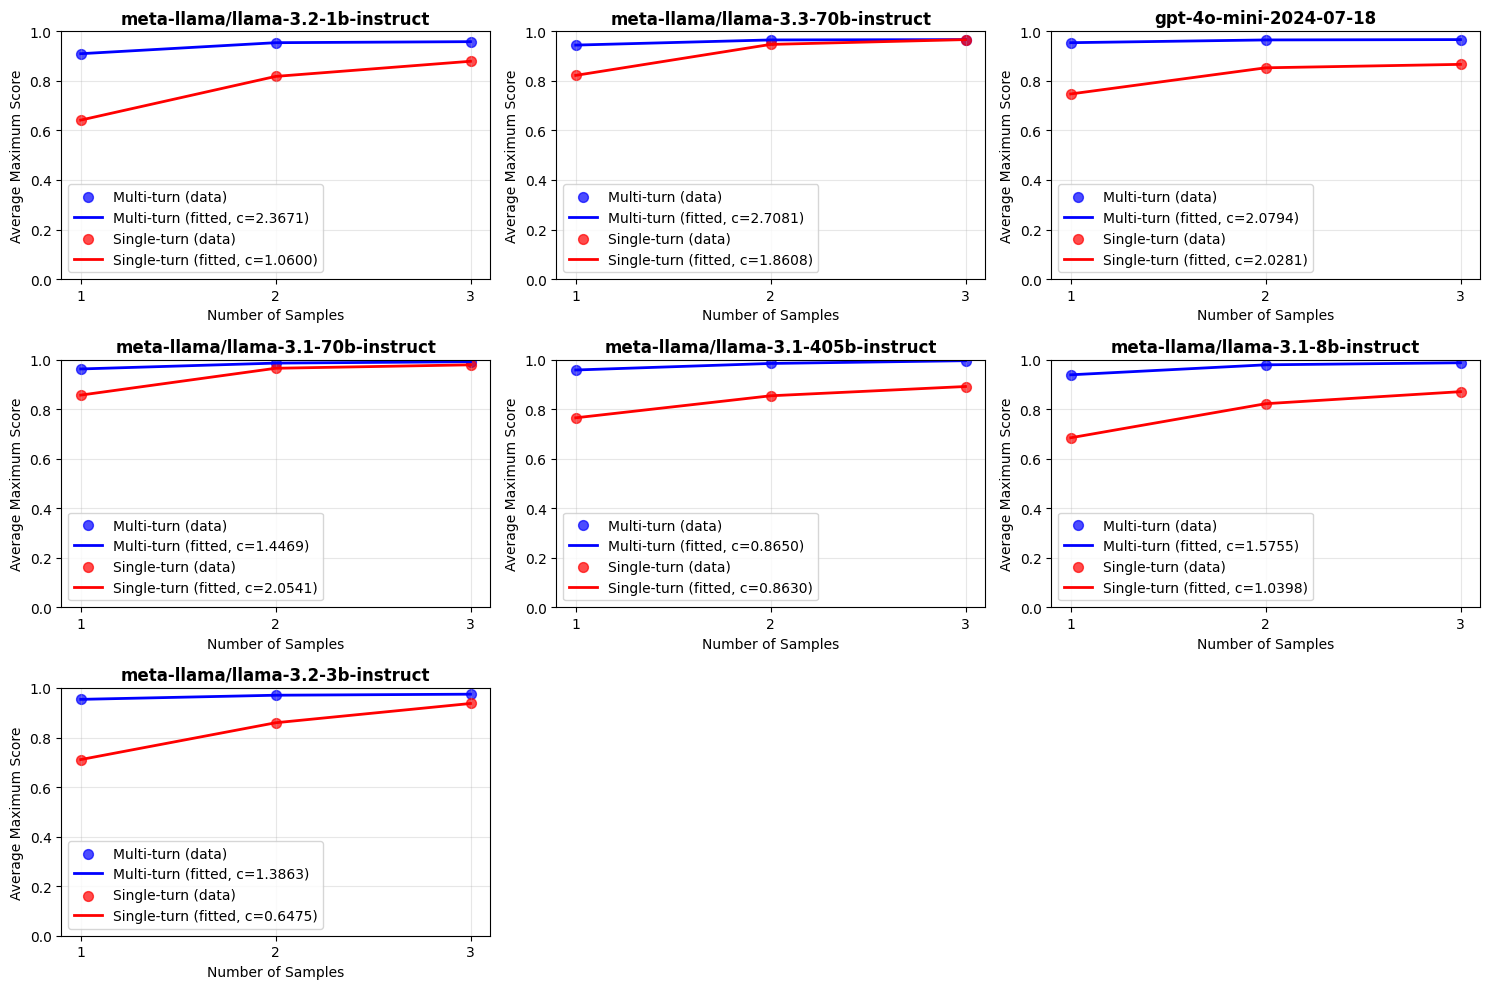

In [10]:
# Plot results by turn type (main analysis)
plot_max_scores_by_model(metadata, by_turn_type=True)

In [11]:
# Show specific example (similar to reference notebook)
results = analyze_max_scores_by_model(metadata[metadata["turn_type"]=="multi"])
if results:
    # Get first model as example
    example_model = list(results.keys())[0]
    example_data = results[example_model]
    print(f"Example results for {example_model} (multi-turn):")
    print(example_data)

Example results for meta-llama/llama-3.2-1b-instruct (multi-turn):
   s  avg_max_score
0  1       0.909722
1  2       0.954167
2  3       0.958333


RMSE: 0.0000


/tmp/ipykernel_1725875/1161316618.py:11: OptimizeWarning: Covariance of the parameters could not be estimated
  params, covariance = curve_fit(formula, s_data, y_data, p0=initial_guess)


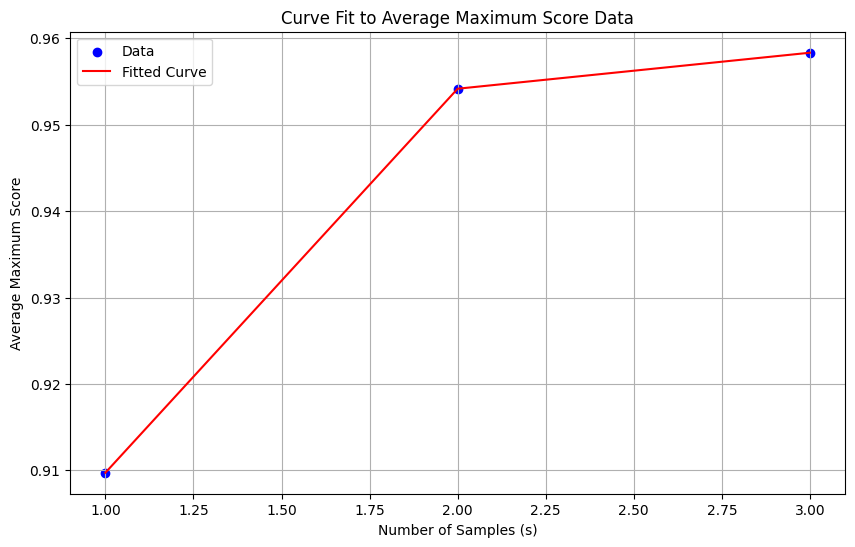

Fitted parameters:
A: 0.9588, B: 0.5231, c: 2.3671


In [12]:
# Plot curve fit for the example (matching reference notebook)
if results:
    plot_curve_fit(example_data['s'], example_data['avg_max_score'])